# 01 — Data Exploration
## Cedar Creek Fire, Eugene OR — Aug–Sep 2022

This notebook loads all three raw data sources, checks coverage, and produces
an initial visual overview before any cleaning or merging.

**Sources:**
- PurpleAir — 57 community sensors, 60-min averages
- NOAA ASOS KEUG — sub-hourly METAR observations, Eugene airport
- LRAPA — hourly regulatory PM2.5, 7 Lane County stations

In [1]:
import sys
sys.path.append("../src")

from data_loader import PurpleAirLoader, NOAALoader, LRAPALoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1. PurpleAir Data

In [2]:
pa_loader = PurpleAirLoader(data_dir="../data/raw/purpleair")
pa_raw = pa_loader.load_all_sensors_in_directory()

print(f"\nShape:    {pa_raw.shape}")
print(f"Sensors:  {pa_raw['sensor_id'].nunique()}")
print(f"Columns:  {pa_raw.columns.tolist()}")
print(f"Date range: {pa_raw['timestamp'].min()} → {pa_raw['timestamp'].max()}")
pa_raw.head(3)

Skipping bogus export(s) (filename starts with space; empty/failed download — you can delete these files):
  ../data/raw/purpleair/PurpleAir Download 5-5-2026/ 2022-08-01 2022-09-30 60-Minute Average.csv
  ../data/raw/purpleair/PurpleAir Download 5-17-2026/ 2020-08-01 2020-10-15 60-Minute Average.csv
Found 79 sensor data files

Shape:    (87167, 14)
Sensors:  52
Columns:  ['time_stamp', 'humidity_a', 'temperature_a', 'pressure_a', 'pm2.5_alt_a', 'pm2.5_atm_a', 'pm2.5_cf_1_a', 'pm2.5_cf_1_b', 'timestamp', 'sensor_id', 'humidity', 'temperature', 'pm2.5_atm', 'pm2.5_cf_1']
Date range: 2020-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00


,time_stamp,humidity_a,temperature_a,pressure_a,pm2.5_alt_a,pm2.5_atm_a,pm2.5_cf_1_a,pm2.5_cf_1_b,timestamp,sensor_id,humidity,temperature,pm2.5_atm,pm2.5_cf_1
0,2022-07-31 17:00:00-07:00,36.0,95.0,988.47,5.1,6.7,6.7,7.1,2022-07-31 17:00:00-07:00,143614,NaN,NaN,NaN,NaN
1,2022-07-31 18:00:00-07:00,40.0,91.0,988.02,5.4,7.2,7.2,7.4,2022-07-31 18:00:00-07:00,143614,NaN,NaN,NaN,NaN
2,2022-07-31 19:00:00-07:00,42.0,89.0,988.33,5.2,6.9,6.9,7.1,2022-07-31 19:00:00-07:00,143614,NaN,NaN,NaN,NaN


In [3]:
# Per-sensor coverage: how many hourly readings does each sensor have?
expected_hours = 61 * 24  # Aug 1 – Sep 30
sensor_counts = pa_raw.groupby('sensor_id')['timestamp'].count().sort_values()
coverage_pct = (sensor_counts / expected_hours * 100).round(1)

print(f"Expected readings per sensor: {expected_hours}")
print(f"\nCoverage (%):")
print(coverage_pct.to_string())
print(f"\nMedian coverage: {coverage_pct.median():.1f}%")
print(f"Sensors with >90% coverage: {(coverage_pct > 90).sum()}")

Expected readings per sensor: 1464

Coverage (%):
sensor_id
80413       0.3
155233      8.2
155127     13.0
154407     13.4
115693     29.5
85073      31.4
120349     40.0
117013     45.6
76761      46.1
108690     67.6
38595      81.7
153576     82.0
122007     83.8
72495      93.6
120809     94.9
109176     97.3
119025     97.9
137786     98.0
84517      98.1
86181      98.2
143614     98.3
107766     98.3
81867      98.4
109468     98.4
111872     98.4
57669      98.4
126471     98.4
114419     98.4
101485     98.4
85283      98.4
119947     98.4
115983     98.4
146152     98.4
114523     98.4
146502     98.4
78281      98.7
78825      98.8
56961     136.5
3904      147.1
65221     152.9
35277     210.5
34927     213.1
5432      213.9
10642     219.5
10614     219.9
2572      219.9
34799     221.0
38823     221.2
3911      221.3
38749     221.3
3419      221.3
34195     221.3

Median coverage: 98.4%
Sensors with >90% coverage: 39


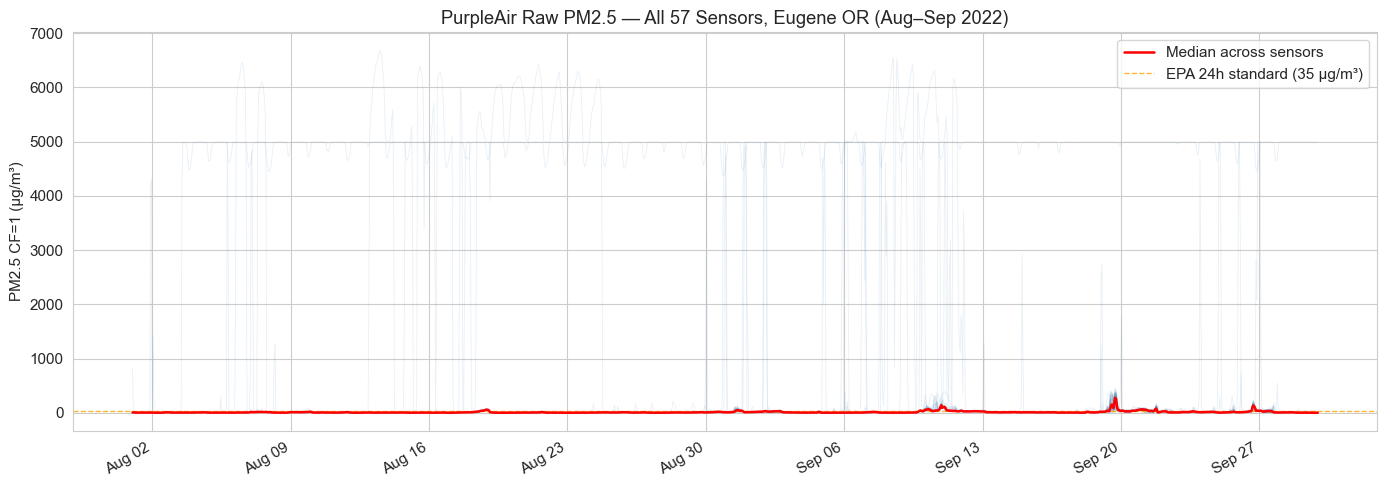

In [4]:
# Raw PM2.5 time series — all sensors (gray) + median (red)
fig, ax = plt.subplots(figsize=(14, 5))

for sid, grp in pa_raw.groupby('sensor_id'):
    ax.plot(grp['timestamp'], grp['pm2.5_cf_1_a'],
            alpha=0.12, color='steelblue', linewidth=0.6)

median_ts = pa_raw.groupby('timestamp')['pm2.5_cf_1_a'].median()
ax.plot(median_ts.index, median_ts.values,
        color='red', linewidth=1.8, label='Median across sensors', zorder=5)

ax.axhline(35, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='EPA 24h standard (35 µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 CF=1 (µg/m³)')
ax.set_title('PurpleAir Raw PM2.5 — All 57 Sensors, Eugene OR (Aug–Sep 2022)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NOAA Weather Data (KEUG — Eugene Airport)

In [5]:
noaa_loader = NOAALoader(data_dir="../data/raw/noaa")
noaa_raw = noaa_loader.load_all_weather_data()

# Keep only the EUG station (Eugene airport ASOS); drop the 77S auxiliary station
noaa_eug = noaa_raw[noaa_raw['station'] == 'EUG'].copy()
print(f"NOAA raw records (all stations): {len(noaa_raw)}")
print(f"NOAA EUG records:                {len(noaa_eug)}")
print(f"Date range: {noaa_eug['timestamp'].min()} → {noaa_eug['timestamp'].max()}")
print(f"\nWeather columns available: {[c for c in noaa_eug.columns if c not in ['station','valid','timestamp','metar']]}")
noaa_eug[['timestamp','temperature_f','humidity','wind_speed_mph','wind_direction','pressure_hpa']].head(5)

Detected data source: metar
Detected data source: metar
NOAA raw records (all stations): 19941
NOAA EUG records:                5932
Date range: 2020-07-31 17:54:00-07:00 → 2022-11-29 15:54:00-08:00

Weather columns available: ['tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'p01i', 'alti', 'mslp', 'vsby', 'gust', 'skyc1', 'skyc2', 'skyc3', 'skyc4', 'skyl1', 'skyl2', 'skyl3', 'skyl4', 'wxcodes', 'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr', 'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time', 'feel', 'snowdepth', 'temperature_f', 'temperature_c', 'dewpoint_f', 'dewpoint_c', 'humidity', 'pressure_hpa', 'wind_speed_knots', 'wind_speed_mph', 'wind_speed_mps', 'wind_direction', 'precipitation_in', 'precipitation_mm', 'visibility_miles', 'visibility_km']


,timestamp,temperature_f,humidity,wind_speed_mph,wind_direction,pressure_hpa
2,2020-07-31 17:54:00-07:00,85.0,33.57,12.65858,250.0,1016.3
6,2020-07-31 18:54:00-07:00,78.0,43.30,12.65858,260.0,1016.9
10,2020-07-31 19:54:00-07:00,74.0,51.64,11.50780,240.0,1017.5
14,2020-07-31 20:54:00-07:00,71.0,54.73,9.20624,240.0,1017.9
18,2020-07-31 21:54:00-07:00,68.0,63.12,5.75390,230.0,1018.4


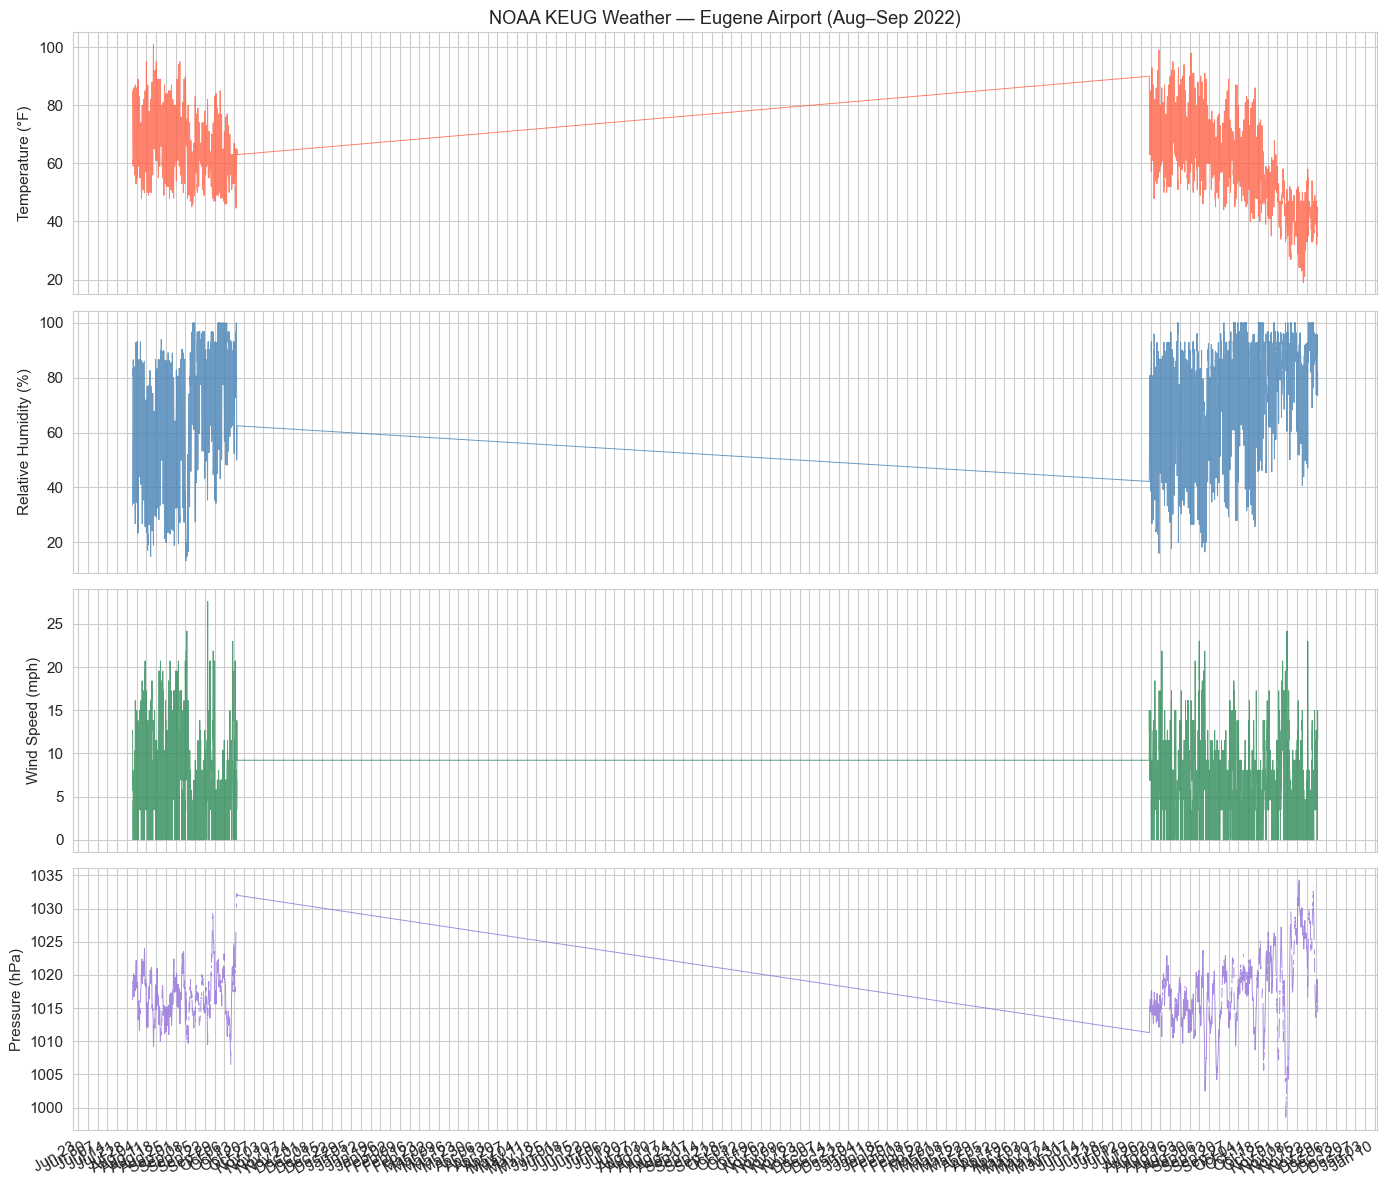

In [6]:
# NOAA weather overview — four-panel time series
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
weather_vars = [
    ('temperature_f', 'Temperature (°F)', 'tomato'),
    ('humidity',      'Relative Humidity (%)', 'steelblue'),
    ('wind_speed_mph','Wind Speed (mph)', 'seagreen'),
    ('pressure_hpa',  'Pressure (hPa)', 'mediumpurple'),
]
for ax, (col, label, color) in zip(axes, weather_vars):
    if col in noaa_eug.columns:
        ax.plot(noaa_eug['timestamp'], noaa_eug[col], color=color, linewidth=0.7, alpha=0.8)
        ax.set_ylabel(label)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0].set_title('NOAA KEUG Weather — Eugene Airport (Aug–Sep 2022)')
plt.tight_layout()
plt.savefig('../data/processed/fig_noaa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LRAPA Regulatory Data

In [7]:
lrapa_loader = LRAPALoader(data_dir="../data/raw/lrapa")
lrapa_raw = lrapa_loader.load_all_lrapa_data()
print(lrapa_loader.get_data_summary(lrapa_raw))
lrapa_raw.head(3)

Loaded 1824 LRAPA records from LRAPAHourlyDataExport05172026-2.xlsx
Date range: 2020-08-01 02:00:00-07:00 → 2020-10-16 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
Loaded 1464 LRAPA records from LRAPAHourlyDataExport05052026-2.xlsx
Date range: 2022-08-01 02:00:00-07:00 → 2022-10-01 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
{'n_records': 3288, 'date_range': (Timestamp('2020-08-01 02:00:00-0700', tz='America/Los_Angeles'), Timestamp('2022-10-01 01:00:00-0700', tz='America/Los_Angeles')), 'columns': ['pm2.5_cottage_grove', 'pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield', 'timestamp', 'pm2.5_lrapa_regulatory', 'pm2.5_florence', 'pm2.5_oakridge'], 'missing': {'pm2.5_cottage_grove': 6, 'pm2.5_amazon_park': 4, 'pm2.5_highway_99': 3, 'pm2.5_santa_clara': 4, 'pm2.5_springfield': 3, 'timestam

,pm2.5_cottage_grove,pm2.5_amazon_park,pm2.5_highway_99,pm2.5_santa_clara,pm2.5_springfield,timestamp,pm2.5_lrapa_regulatory,pm2.5_florence,pm2.5_oakridge
0,2.88,1.59,1.68,3.15,2.17,2020-08-01 02:00:00-07:00,2.1475,NaN,NaN
1,3.03,1.36,1.41,3.01,1.97,2020-08-01 03:00:00-07:00,1.9375,NaN,NaN
2,3.14,1.32,1.07,2.98,1.87,2020-08-01 04:00:00-07:00,1.8100,NaN,NaN


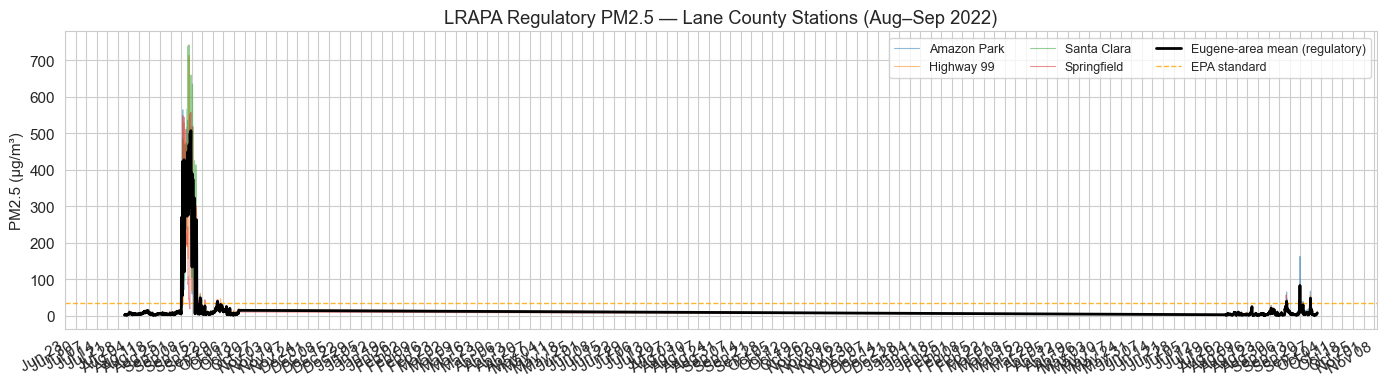

In [8]:
# LRAPA all stations + regulatory mean
station_cols = ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
station_cols = [c for c in station_cols if c in lrapa_raw.columns]

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for col, color in zip(station_cols, colors):
    ax.plot(lrapa_raw['timestamp'], lrapa_raw[col],
            alpha=0.5, linewidth=0.8, color=color, label=col.replace('pm2.5_', '').replace('_', ' ').title())

ax.plot(lrapa_raw['timestamp'], lrapa_raw['pm2.5_lrapa_regulatory'],
        color='black', linewidth=2, label='Eugene-area mean (regulatory)', zorder=5)
ax.axhline(35, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='EPA standard')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('LRAPA Regulatory PM2.5 — Lane County Stations (Aug–Sep 2022)')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('../data/processed/fig_lrapa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Missing Data Summary

In [9]:
print("=== Missing Data Summary ===")
print(f"\nPurpleAir (per key column):")
for col in ['pm2.5_cf_1_a', 'pm2.5_cf_1_b', 'pm2.5_alt_a', 'humidity_a']:
    if col in pa_raw.columns:
        pct = pa_raw[col].isna().mean() * 100
        print(f"  {col:25s}: {pct:.1f}% missing")

print(f"\nNOAA EUG (per key column):")
for col in ['temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']:
    if col in noaa_eug.columns:
        pct = noaa_eug[col].isna().mean() * 100
        print(f"  {col:25s}: {pct:.1f}% missing")

print(f"\nLRAPA regulatory:")
pct = lrapa_raw['pm2.5_lrapa_regulatory'].isna().mean() * 100
print(f"  pm2.5_lrapa_regulatory  : {pct:.1f}% missing")

=== Missing Data Summary ===

PurpleAir (per key column):
  pm2.5_cf_1_a             : 28.3% missing
  pm2.5_cf_1_b             : 0.0% missing
  pm2.5_alt_a              : 28.3% missing
  humidity_a               : 30.3% missing

NOAA EUG (per key column):
  temperature_f            : 0.1% missing
  humidity                 : 0.1% missing
  wind_speed_mph           : 0.2% missing
  pressure_hpa             : 20.9% missing

LRAPA regulatory:
  pm2.5_lrapa_regulatory  : 0.0% missing
